## Results Summary

| Model | Recall | F1 | ROC-AUC |
|-------|--------|----|---------|
| Random Forest | 97.18% | 91.46% | 98.42% |
| XGBoost | 96.73% | 90.79% | 98.16% |
| IsolationForest (unsupervised) | 13.95% | 21.69% | 64.73% |

Chosen model: Random Forest
Isolation Forest had AUC of 0.647, so it is practical for real-world environments with limited labeled attack data

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Model libraries
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,         # Overall perecnt correct
    precision_score,        # How many predicted attacks were real
    recall_score,           # How many real attacks caught
    f1_score,               # Mean of precision and recall
    roc_auc_score,          # Overall discriminability
    classification_report,  # Class breakdown
    ConfusionMatrixDisplay, # Visual confusion matrix
    roc_curve               # To plot ROC curves
)

In [49]:
train = pd.read_csv('../data/train_features.csv')
test  = pd.read_csv('../data/test_features.csv')

drop_cols = ['label', 'attack_cat']
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
y_train = train['label']
X_test  = test[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
y_test  = test['label']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Attack rate — Train: {y_train.mean()*100:.1f}%, Test: {y_test.mean()*100:.1f}%")
# High attack rate since dataset is researched/balanced, real-world traffic attack rate is lower

Train: (175341, 194), Test: (82332, 194)
Attack rate — Train: 68.1%, Test: 55.1%


In [50]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """
    Evaluation summary for model
    
    y_true: Labels from the test set
    y_pred: Binary predictions from model.predict()
    y_prob  Probability scores from predict_proba()[:,1] or decision_function() (for IsolationForest)
    """
    print(f"  {name}")
    
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Attack']))

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}") 
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")  
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")    
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")         
    
    if y_prob is not None:
        print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")

In [51]:
# Model 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_preds, rf_proba)

  Random Forest
              precision    recall  f1-score   support

      Normal       0.96      0.81      0.88     37000
      Attack       0.86      0.97      0.91     45332

    accuracy                           0.90     82332
   macro avg       0.91      0.89      0.90     82332
weighted avg       0.91      0.90      0.90     82332

Accuracy : 0.9001
Precision: 0.8637
Recall   : 0.9718
F1 Score : 0.9146
ROC-AUC  : 0.9842


In [52]:
# XGBoost 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,          
    max_depth=6,              
    subsample=0.8,           
    colsample_bytree=0.8,    
    scale_pos_weight=scale_pos_weight,  
    random_state=42,
    eval_metric='logloss',    
    verbosity=0,              
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost", y_test, xgb_preds, xgb_proba)

scale_pos_weight: 0.47
  XGBoost
              precision    recall  f1-score   support

      Normal       0.95      0.80      0.87     37000
      Attack       0.86      0.97      0.91     45332

    accuracy                           0.89     82332
   macro avg       0.90      0.88      0.89     82332
weighted avg       0.90      0.89      0.89     82332

Accuracy : 0.8920
Precision: 0.8554
Recall   : 0.9673
F1 Score : 0.9079
ROC-AUC  : 0.9816


In [53]:
# Model 3: IsolationForest
iso = IsolationForest(
    contamination=0.15, 
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

iso_raw   = iso.predict(X_test)

iso_preds = (iso_raw == -1).astype(int)

iso_scores = iso.decision_function(X_test)

evaluate_model("IsolationForest", y_test, iso_preds, iso_scores)

  IsolationForest
              precision    recall  f1-score   support

      Normal       0.44      0.82      0.57     37000
      Attack       0.49      0.14      0.22     45332

    accuracy                           0.45     82332
   macro avg       0.46      0.48      0.39     82332
weighted avg       0.46      0.45      0.38     82332

Accuracy : 0.4454
Precision: 0.4874
Recall   : 0.1395
F1 Score : 0.2169
ROC-AUC  : 0.6473


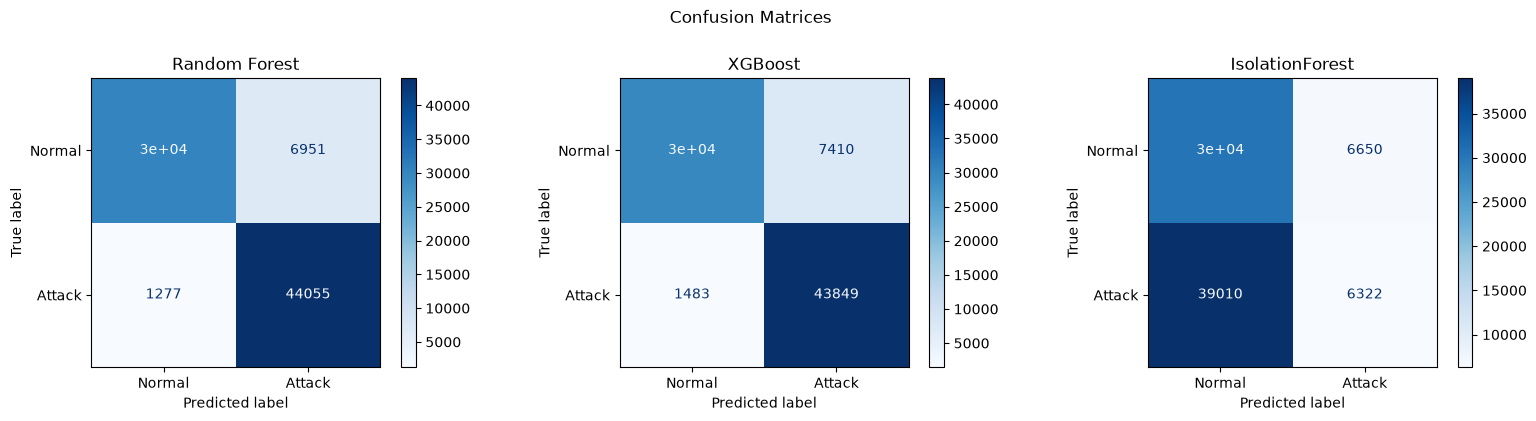

In [54]:
# Confusion matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, preds) in zip(axes, [
    ("Random Forest",   rf_preds),
    ("XGBoost",         xgb_preds),
    ("IsolationForest", iso_preds)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["Normal", "Attack"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.savefig('../static/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

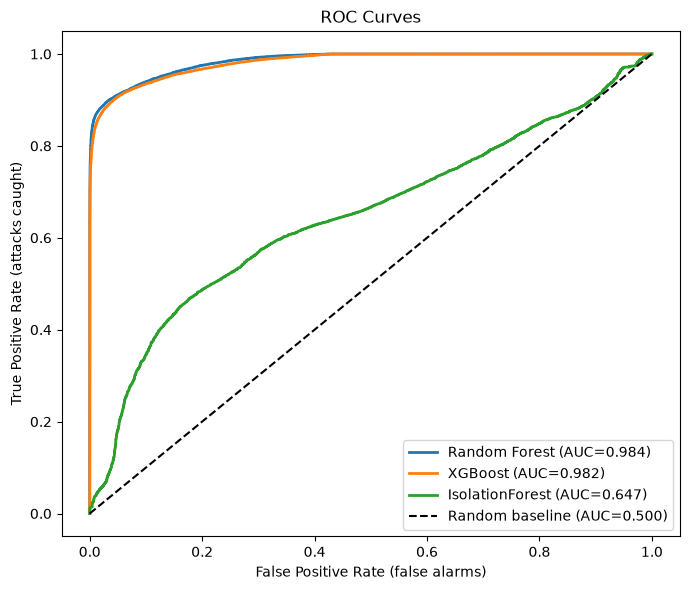

In [55]:
# ROC curve plots
# Plotting on one graph for easy comparison

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob in [
    ("Random Forest",            rf_proba),
    ("XGBoost",                  xgb_proba),
    ("IsolationForest",          iso_scores),  # Anomaly scores
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

# Diagonal = random baseline, useful models should be above
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC=0.500)')

ax.set_xlabel("False Positive Rate (false alarms)")
ax.set_ylabel("True Positive Rate (attacks caught)")
ax.set_title("ROC Curves")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../static/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

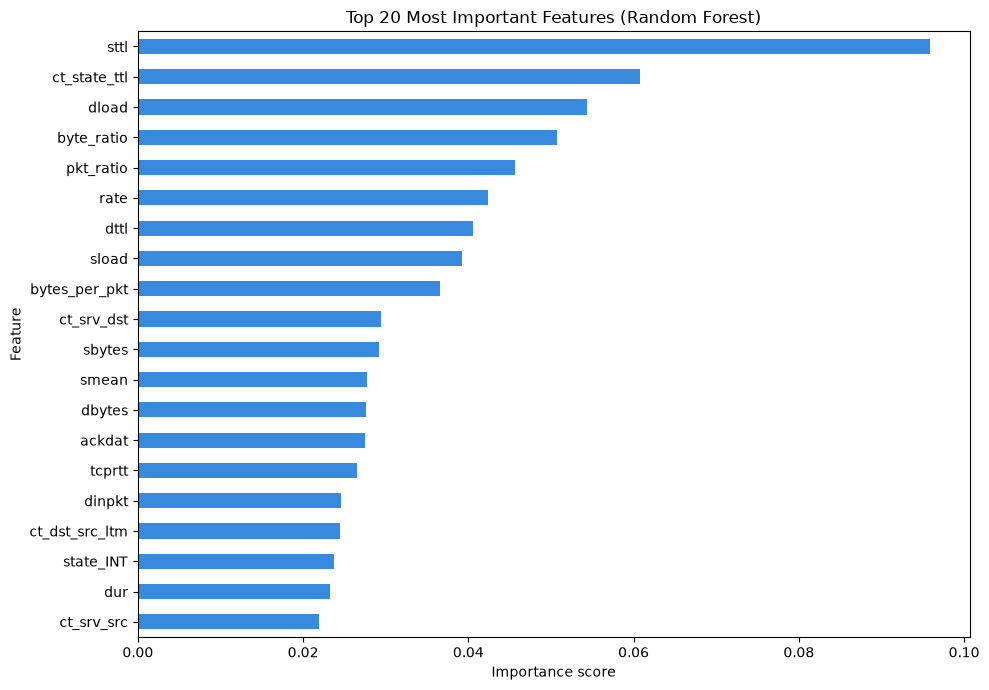


Engineered features in top 20:
  byte_ratio — rank #4
  pkt_ratio — rank #5
  bytes_per_pkt — rank #9


In [56]:
# Feature importance

importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title('Top 20 Most Important Features (Random Forest)')
ax.set_xlabel('Importance score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../static/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nEngineered features in top 20:")
engineered = ['byte_ratio', 'pkt_ratio', 'bytes_per_pkt']
for feat in engineered:
    if feat in top20.index:
        rank = list(top20.sort_values(ascending=False).index).index(feat) + 1
        print(f"  {feat} — rank #{rank}")

In [63]:
# Comparison table

results = {}
for name, preds, proba in [
    ("Random Forest",   rf_preds,  rf_proba),
    ("XGBoost",         xgb_preds, xgb_proba),
    ("IsolationForest", iso_preds, iso_scores),
]:
    results[name] = {
        'Accuracy (%)':  round(accuracy_score(y_test, preds)  * 100, 2),
        'Precision (%)': round(precision_score(y_test, preds) * 100, 2),
        'Recall (%)':    round(recall_score(y_test, preds)    * 100, 2),
        'F1 (%)':        round(f1_score(y_test, preds)        * 100, 2),
        'ROC-AUC (%)':   round(roc_auc_score(y_test, proba)   * 100, 2),
    }

results_df = pd.DataFrame(results).T
print("\nModel Comparison Summary")
print("="*77)
print(results_df.to_string())


Model Comparison Summary
                 Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%)
Random Forest           90.01          86.37       97.18   91.46        98.42
XGBoost                 89.20          85.54       96.73   90.79        98.16
IsolationForest         44.54          48.74       13.95   21.69        64.73


In [ ]:
# Trained models for Dashboard

with open('../src/rf_model.pkl', 'wb') as f:
    pickle.dump((rf, feature_cols), f)

with open('../src/xgb_model.pkl', 'wb') as f:
    pickle.dump((xgb_model, feature_cols), f)

with open('../src/iso_model.pkl', 'wb') as f:
    pickle.dump((iso, feature_cols), f)